# Tutorial: MediaPipe Facial Landmarks on an Image

Audience:
- Anyone working in this repo who wants a minimal MediaPipe image demo.

Prerequisites:
- The repo environment from `AGENTS.md` is installed.
- `mediapipe`, `opencv-python`, `matplotlib`, and `pandas` are available.

Learning goals:
- Load a single image.
- Detect MediaPipe face landmarks.
- Visualize and save the annotated output.
- Inspect the first few landmark coordinates in a table.


## Outline

1. Resolve paths and imports.
2. Configure the input image and output location.
3. Run MediaPipe FaceMesh on the image.
4. Visualize the original image next to the annotated result.
5. Review a small landmark coordinate table.


In [1]:
from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import pandas as pd

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "openwillis-face").exists() and (candidate / "sample_data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
REPO_ROOT


PosixPath('/Users/pelmeshek1706/Desktop/projects/airest-face')

In [2]:
IMAGE_PATH = REPO_ROOT / "output" / "jupyter-notebook" / "assets" / "expressive_first_frame.jpg"
OUTPUT_PATH = REPO_ROOT / "output" / "jupyter-notebook" / "assets" / "expressive_first_frame_landmarks.jpg"

# Replace IMAGE_PATH with any other local image if needed.
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Input image not found: {IMAGE_PATH}")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
IMAGE_PATH, OUTPUT_PATH


(PosixPath('/Users/pelmeshek1706/Desktop/projects/airest-face/output/jupyter-notebook/assets/expressive_first_frame.jpg'),
 PosixPath('/Users/pelmeshek1706/Desktop/projects/airest-face/output/jupyter-notebook/assets/expressive_first_frame_landmarks.jpg'))

## Run FaceMesh

This cell loads the image, detects facial landmarks, draws the tessellation, contours, and irises, then writes the annotated image to disk.

In [3]:
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise ValueError(f"OpenCV could not read the image: {IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:
    results = face_mesh.process(image_rgb)

if not results.multi_face_landmarks:
    raise RuntimeError("MediaPipe did not detect a face in the selected image.")

annotated_image = image_rgb.copy()
for face_landmarks in results.multi_face_landmarks:
    mp_drawing.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=mp_face_mesh.FACEMESH_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style(),
    )
    mp_drawing.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=mp_face_mesh.FACEMESH_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_contours_style(),
    )
    mp_drawing.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=mp_face_mesh.FACEMESH_IRISES,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_iris_connections_style(),
    )

cv2.imwrite(str(OUTPUT_PATH), cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
print(f"Detected {len(results.multi_face_landmarks[0].landmark)} landmarks.")
print(f"Annotated image saved to: {OUTPUT_PATH}")


Detected 478 landmarks.
Annotated image saved to: /Users/pelmeshek1706/Desktop/projects/airest-face/output/jupyter-notebook/assets/expressive_first_frame_landmarks.jpg


I0000 00:00:1779450136.322512 15322160 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779450136.331703 15323137 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779450136.337452 15323136 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779450136.339770 15323140 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


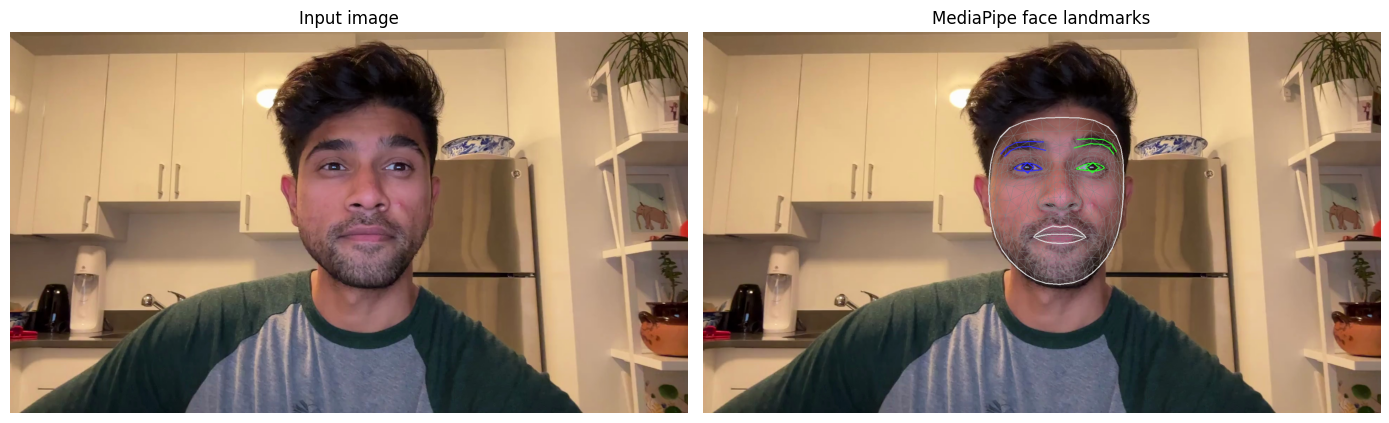

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(image_rgb)
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(annotated_image)
axes[1].set_title("MediaPipe face landmarks")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Landmark Preview

MediaPipe returns normalized `x`, `y`, and `z` coordinates. The table below shows the first ten landmarks from the detected face.

In [5]:
first_face = results.multi_face_landmarks[0]
landmark_df = pd.DataFrame(
    [
        {"landmark_index": index, "x": lmk.x, "y": lmk.y, "z": lmk.z}
        for index, lmk in enumerate(first_face.landmark)
    ]
)

landmark_df.head(10)


,landmark_index,x,y,z
0,0,0.527152,0.513469,-0.028569
1,1,0.526875,0.452795,-0.049236
2,2,0.526009,0.470914,-0.027368
3,3,0.518857,0.397353,-0.035163
4,4,0.527018,0.434920,-0.051742
5,5,0.526912,0.412516,-0.047308
6,6,0.526385,0.360610,-0.020497
7,7,0.462287,0.363221,0.014329
8,8,0.526243,0.321839,-0.012726
9,9,0.526338,0.299876,-0.013477


## Swap the Input Image

To run this on a different image, change `IMAGE_PATH` in the configuration cell to another local `.jpg`, `.jpeg`, or `.png` file and rerun the notebook from the top.